In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [22]:
xArray = np.linspace(0,2*np.pi, 100)

def function(x):
    a = 1.0
    b = 1.0
    yAnswer = a * np.exp(-b * x)
    return yAnswer
def createSigma():
    #x will probably be xArray? 
    """
    has to decrease linearly going from 2 to 0,2
    """
    sigmaError = np.linspace(2,0.2,100)
    return sigmaError

In [23]:
def fitOne(x, a, b):
    yOne = a * np.exp(-b * x)
    return yOne
def fitTwo(x,a,b):
    yTwo = a / (x**b)
    return yTwo

In [24]:
arrayNew = np.zeros(99)
for i in range(99):
    arrayNew[i] = xArray[i+1]
#print(arrayNew)

The slope for Fit One is 0.6533, and the y-intercept for Fit One is 0.6509
The slope for Fit Two is 0.0506, and the y-intercept for Fit One is 0.4212


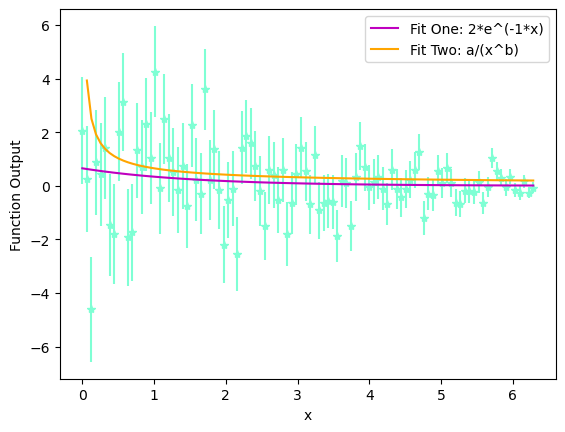

In [25]:
yData = function(xArray)
sigmaMade = createSigma()
scatter = np.random.normal(scale = sigmaMade, size  = 100)
yScatter = yData + scatter


sigmaErrorNew = np.linspace(2,0.2,99)

scatterNew = np.zeros(99)
for i in range(99):
    scatterNew[i] = yScatter[i+1]

yError = np.full(100, sigmaMade)

yErrorNew = np.full(99,sigmaErrorNew)

params, params_cov = curve_fit(fitOne, xArray, yScatter, sigma = yError)
m1 = params[0]
b1 = params[1]
yFit1 = fitOne(xArray, m1, b1)
plt.plot(xArray, yFit1, label = "Fit One: 2*e^(-1*x)", c = "m")

params, params_cov = curve_fit(fitTwo, arrayNew, scatterNew, sigma = yErrorNew)
m2 = params[0]
b2 = params[1]
yFit2 = fitTwo(arrayNew, m1, b1)
plt.plot(arrayNew, yFit2, label = "Fit Two: a/(x^b)", c = "orange")

print(f"The slope for Fit One is {m1:5.4f}, and the y-intercept for Fit One is {b1:5.4f}")
print(f"The slope for Fit Two is {m2:5.4f}, and the y-intercept for Fit One is {b2:5.4f}")

#plt.plot(xArray, yData, c = "k", zorder = 1)
plt.errorbar(xArray, yScatter, yerr = yError, fmt = "*", zorder = 0, c = "aquamarine")
plt.xlabel("x")
plt.ylabel("Function Output")
plt.legend()
plt.savefig("Journal2-Prompt3 Graph", bbox_inches = "tight", dpi = 400)